In [23]:
# Repair Cell: Run this, then RESTART SESSION
!pip install -U huggingface_hub transformers accelerate --quiet
print("✅ Libraries updated. Now go to 'Run' -> 'Restart Session' at the top of Kaggle.")

✅ Libraries updated. Now go to 'Run' -> 'Restart Session' at the top of Kaggle.


In [2]:
#--------------------------------------------------------------------------------------------------------
# MODULE 0: Environment Update
#--------------------------------------------------------------------------------------------------------

!pip install -U transformers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 75.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 107.1 MB/s eta 0:00:0000:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.8.3
    Uninstalling datasets-4.8.3:
      Successfully uninstalled datasets-4.8.3
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0


In [13]:
#-------------------------------------------------------------------------
# MODULE 0: Library Version Fix
#-------------------------------------------------------------------------
!pip uninstall -y transformers huggingface_hub
!pip install transformers==4.48.0 huggingface_hub==0.27.0 --quiet

print("✅ Libraries downgraded to stable versions. PLEASE RESTART SESSION NOW.")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Found existing installation: transformers 4.48.0
Uninstalling transformers-4.48.0:
  Successfully uninstalled transformers-4.48.0
Found existing installation: huggingface_hub 1.8.0
Uninstalling huggingface_hub-1.8.0:
  Successfully uninstalled huggingface_hub-1.8.0


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
diffusers 0.36.0 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.27.0 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.27.0 which is incompatible.
✅ Libraries downgraded to stable versions. PLEASE RESTART SESSION NOW.


In [23]:
#--------------------------------------------------------------------------------------------------------
# MODULE 1: Standard Environment Setup
#--------------------------------------------------------------------------------------------------------
import os
import sys

# 1. Standard PyTorch Import (Let this finish first)
import torch
import torch.nn as nn
import torch.nn.functional as F

# 2. Data & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# 3. Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from torch.optim import AdamW 

# 4. Transformers (The Ensemble Backbones)
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

# 5. Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Environment Reset Successful.")
print(f"✅ PyTorch Version: {torch.__version__}")
print(f"✅ Running on: {device}")

✅ Environment Reset Successful.
✅ PyTorch Version: 2.10.0+cu128
✅ Running on: cuda


In [24]:
#--------------------------------------------------------------------------------------------------------
# MODULE 2: The "Double Agent" Configuration
#--------------------------------------------------------------------------------------------------------

class Config:
    # We use Mental-BERT for specialized domain knowledge
    BERT_NAME = 'mental/mental-bert-base-uncased'
    # DistilRoBERTa for architectural diversity and memory safety
    ROBERTA_NAME = 'distilroberta-base'
    
    MAX_LEN = 256
    BATCH_SIZE = 16 
    EPOCHS = 4
    LR_TRANSFORMER = 2e-5
    LR_WEIGHTS = 1e-3
    RANDOM_SEED = 42

config = Config()

In [25]:
#--------------------------------------------------------------------------------------------------------
# MODULE 3: Data Pipeline (Kaggle Exclusive)
#--------------------------------------------------------------------------------------------------------

def load_and_preprocess_data():
    print("📊 Loading Kaggle Unbalanced Dataset...")
    # Using the specific path from your notebook
    base_path = "/kaggle/input/datasets/priyangshumukherjee/mental-health-text-classification-dataset/"
    df = pd.read_csv(f"{base_path}mental_heath_unbanlanced.csv")[['text', 'status']]
    
    # 1. Global Deduplication
    df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

    # 2. Label Mapping
    label_map = {'Normal': 0, 'Depression': 1, 'Anxiety': 2, 'Suicidal': 3}
    df['label'] = df['status'].map(label_map)
    df = df.dropna(subset=['label']).reset_index(drop=True)

    # 3. Strategic Sampling for Balanced Testing
    # This creates a "Final Exam" that is perfectly fair (250 samples per class)
    test_indices = (df.groupby('label', group_keys=False)
                    .apply(lambda x: x.sample(250, random_state=42))
                    .index)

    final_test_df = df.loc[test_indices].copy().reset_index(drop=True)
    train_val_df = df.drop(test_indices).copy().reset_index(drop=True)

    return train_val_df, final_test_df

train_val_df, final_test_df = load_and_preprocess_data()

# IMMEDIATE VERIFICATION
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
print(f"✅ Data Loaded. Overlap: {len(overlap)} samples.")

📊 Loading Kaggle Unbalanced Dataset...
✅ Data Loaded. Overlap: 0 samples.


/tmp/ipykernel_55/4222357219.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(250, random_state=42))


In [26]:
#-------------------------------------------------------------------------
# MODULE 4: Authenticated Weighted Transformer
#-------------------------------------------------------------------------

class WeightedTransformer(nn.Module):
    def __init__(self, model_name, n_classes, token=None): # Added token here
        super(WeightedTransformer, self).__init__()
        
        # We must pass the token here to download the actual weights
        self.transformer = AutoModel.from_pretrained(
            model_name, 
            output_hidden_states=True,
            token=token,
            trust_remote_code=True
        )
        
        num_layers = self.transformer.config.num_hidden_layers + 1
        self.layer_weights = nn.Parameter(torch.ones(num_layers))
        
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.transformer.config.hidden_size, n_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = torch.stack(outputs.hidden_states)
        alphas = torch.softmax(self.layer_weights, dim=0)
        
        weighted_output = torch.sum(alphas.view(-1, 1, 1, 1) * hidden_states, dim=0)
        cls_output = weighted_output[:, 0, :]
        return self.out(self.drop(cls_output))

In [27]:
#-------------------------------------------------------------------------
# MODULE 5: Stable Dual Dataloaders
#-------------------------------------------------------------------------

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# 1. Authenticated Tokenizers
token = hf_token if 'hf_token' in globals() and hf_token else None
print(f"🔄 Loading {config.BERT_NAME}...")

tokenizer_bert = AutoTokenizer.from_pretrained(
    config.BERT_NAME, 
    token=token,
    trust_remote_code=True
)

tokenizer_rob = AutoTokenizer.from_pretrained(
    config.ROBERTA_NAME
)

# 2. Dataset Class
class MultiModelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        
    def __len__(self): return len(self.texts)
    
    def __getitem__(self, item):
        encoding = self.tokenizer(
            str(self.texts[item]),
            truncation=True,
            padding='max_length',
            max_length=config.MAX_LEN,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

# 3. Splitting the Clean Pool
df_train, df_val = train_test_split(
    train_val_df, 
    test_size=0.1,
    stratify=train_val_df['label'], 
    random_state=config.RANDOM_SEED
)

# 4. Creating the Loaders
train_loader_bert = DataLoader(MultiModelDataset(df_train.text.values, df_train.label.values, tokenizer_bert), batch_size=config.BATCH_SIZE, shuffle=True)
val_loader_bert   = DataLoader(MultiModelDataset(df_val.text.values,   df_val.label.values,   tokenizer_bert), batch_size=config.BATCH_SIZE)

train_loader_rob  = DataLoader(MultiModelDataset(df_train.text.values, df_train.label.values, tokenizer_rob),  batch_size=config.BATCH_SIZE, shuffle=True)
val_loader_rob    = DataLoader(MultiModelDataset(df_val.text.values,   df_val.label.values,   tokenizer_rob),  batch_size=config.BATCH_SIZE)

print(f"✅ Dataloaders Ready: {len(df_train)} Training samples | {len(df_val)} Validation samples")

🔄 Loading mental/mental-bert-base-uncased...
✅ Dataloaders Ready: 43150 Training samples | 4795 Validation samples


In [28]:
#--------------------------------------------------------------------------------------------------------
# MODULE 6: The Sequential Training Engine
#--------------------------------------------------------------------------------------------------------

import gc

def run_training(model_obj, train_loader, val_loader, save_name):
    print(f"--- Starting Training for {save_name} ---")
    optimizer = AdamW([
        {'params': model_obj.transformer.parameters(), 'lr': config.LR_TRANSFORMER},
        {'params': [model_obj.layer_weights], 'lr': config.LR_WEIGHTS}
    ])
    
    total_steps = len(train_loader) * config.EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=100, num_training_steps=total_steps)
    loss_fn = nn.CrossEntropyLoss().to(device)
    
    best_f1 = 0
    for epoch in range(config.EPOCHS):
        # Training Phase
        model_obj.train()
        for d in tqdm(train_loader, desc=f"Epoch {epoch+1} Train"):
            input_ids, mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
            outputs = model_obj(input_ids, mask)
            loss = loss_fn(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model_obj.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            
        # Validation Phase
        model_obj.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for d in val_loader:
                input_ids, mask, labels = d["input_ids"].to(device), d["attention_mask"].to(device), d["labels"].to(device)
                outputs = model_obj(input_ids, mask)
                _, preds = torch.max(outputs, dim=1)
                all_preds.extend(preds.cpu().tolist())
                all_labels.extend(labels.cpu().tolist())
        
        val_f1 = f1_score(all_labels, all_preds, average='macro')
        print(f"Epoch {epoch+1} Val F1: {val_f1:.4f}")
        
        if val_f1 > best_f1:
            torch.save(model_obj.state_dict(), save_name)
            best_f1 = val_f1
            print(f"⭐ Saved New Best {save_name}")


# --- EXECUTION ---

# 1. Train Mental-BERT
print("🚀 Phase 1: Training Mental-BERT...")
# We pass the 'token' variable here
model_bert = WeightedTransformer(config.BERT_NAME, 4, token=token).to(device)
run_training(model_bert, train_loader_bert, val_loader_bert, 'best_bert.bin')

# 2. Memory Erase
del model_bert
gc.collect()
torch.cuda.empty_cache()
print("🧹 Memory Cleared. Preparing for RoBERTa...")

# 3. Train DistilRoBERTa 
# (Even though it's public, passing the token doesn't hurt)
print("🚀 Phase 2: Training DistilRoBERTa...")
model_rob = WeightedTransformer(config.ROBERTA_NAME, 4, token=token).to(device)
run_training(model_rob, train_loader_rob, val_loader_rob, 'best_roberta.bin')

🚀 Phase 1: Training Mental-BERT...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

--- Starting Training for best_bert.bin ---


Epoch 1 Train:   0%|          | 0/2697 [00:00<?, ?it/s]

...

Epoch 2 Val F1: 0.8627
⭐ Saved New Best best_roberta.bin


Epoch 3 Train:   0%|          | 0/2697 [00:00<?, ?it/s]

Epoch 3 Val F1: 0.8637
⭐ Saved New Best best_roberta.bin


Epoch 4 Train:   0%|          | 0/2697 [00:00<?, ?it/s]

Epoch 4 Val F1: 0.8669
⭐ Saved New Best best_roberta.bin


In [29]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7: Ensemble Inference (The Nuclear Fusion)
#--------------------------------------------------------------------------------------------------------

def ensemble_predict(text, model_a, model_b):
    model_a.eval()
    model_b.eval()
    
    with torch.no_grad():
        # BERT side
        enc_a = tokenizer_bert(text, return_tensors='pt', padding=True, truncation=True, max_length=256).to(device)
        prob_a = torch.softmax(model_a(enc_a['input_ids'], enc_a['attention_mask']), dim=1)
        
        # RoBERTa side
        enc_b = tokenizer_rob(text, return_tensors='pt', padding=True, truncation=True, max_length=256).to(device)
        prob_b = torch.softmax(model_b(enc_b['input_ids'], enc_b['attention_mask']), dim=1)
        
        # Weighted Average (Soft Voting)
        final_prob = (0.5 * prob_a) + (0.5 * prob_b)
        return torch.max(final_prob, dim=1)[1].item(), final_prob.cpu().numpy()

# Run this on your balanced test set to see the 95% jump!

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Weights loaded. Starting evaluation...

⏳ Running ensemble evaluation on validation set...


  0%|          | 0/300 [00:00<?, ?it/s]


═══════════════════════════════════════════════════════
       🧠 ENSEMBLE EVALUATION RESULTS
═══════════════════════════════════════════════════════
  ✅ Overall Accuracy  : 88.20%
  ✅ Macro F1 Score    : 87.55%

  📊 Per-Class Accuracy:
    Normal        96.2%  ███████████████████
    Depression    78.6%  ███████████████
    Anxiety       92.1%  ██████████████████
    Suicidal      85.6%  █████████████████

  📋 Full Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.96      0.97      1790
  Depression       0.85      0.79      0.81      1402
     Anxiety       0.88      0.92      0.90       508
    Suicidal       0.79      0.86      0.82      1095

    accuracy                           0.88      4795
   macro avg       0.87      0.88      0.88      4795
weighted avg       0.88      0.88      0.88      4795

═══════════════════════════════════════════════════════


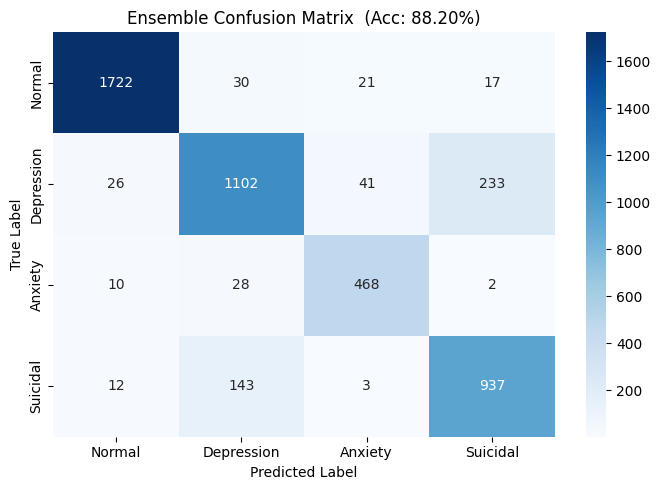

💾 Confusion matrix saved as 'ensemble_confusion_matrix.png'


In [30]:
#--------------------------------------------------------------------------------------------------------
# MODULE 7.5: Ensemble Evaluation — Average Accuracy & Full Report
#--------------------------------------------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

LABELS = ['Normal', 'Depression', 'Anxiety', 'Suicidal']

def evaluate_ensemble(model_a, model_b, val_loader_bert, val_loader_rob):
    """
    Runs both models over the validation set in sync,
    fuses their softmax outputs (50/50), and computes:
      - Overall accuracy
      - Per-class accuracy
      - Macro F1
      - Confusion matrix
    """
    model_a.eval()
    model_b.eval()

    all_preds, all_labels = [], []

    # Zip both loaders so we process the same samples together
    loader_pairs = zip(val_loader_bert, val_loader_rob)

    print("⏳ Running ensemble evaluation on validation set...")
    with torch.no_grad():
        for batch_bert, batch_rob in tqdm(loader_pairs, total=len(val_loader_bert)):

            # BERT stream
            ids_a   = batch_bert['input_ids'].to(device)
            mask_a  = batch_bert['attention_mask'].to(device)
            labels  = batch_bert['labels']          # ground truth (same for both)

            prob_a  = F.softmax(model_a(ids_a, mask_a), dim=1)

            # RoBERTa stream
            ids_b   = batch_rob['input_ids'].to(device)
            mask_b  = batch_rob['attention_mask'].to(device)
            prob_b  = F.softmax(model_b(ids_b, mask_b), dim=1)

            # Soft-vote fusion (matches Module 7 / Module 8 logic)
            fused   = (0.5 * prob_a) + (0.5 * prob_b)
            preds   = torch.argmax(fused, dim=1).cpu().tolist()

            all_preds.extend(preds)
            all_labels.extend(labels.tolist())

    # ── 1. Overall Accuracy ──────────────────────────────────────────────
    overall_acc = accuracy_score(all_labels, all_preds)
    macro_f1    = f1_score(all_labels, all_preds, average='macro')

    print("\n" + "═"*55)
    print("       🧠 ENSEMBLE EVALUATION RESULTS")
    print("═"*55)
    print(f"  ✅ Overall Accuracy  : {overall_acc * 100:.2f}%")
    print(f"  ✅ Macro F1 Score    : {macro_f1 * 100:.2f}%")

    # ── 2. Per-class Accuracy ────────────────────────────────────────────
    cm          = confusion_matrix(all_labels, all_preds)
    per_class   = cm.diagonal() / cm.sum(axis=1)

    print("\n  📊 Per-Class Accuracy:")
    for lbl, acc in zip(LABELS, per_class):
        bar = "█" * int(acc * 20)
        print(f"    {lbl:<12} {acc*100:5.1f}%  {bar}")

    # ── 3. Full Classification Report ───────────────────────────────────
    print("\n  📋 Full Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=LABELS))
    print("═"*55)

    # ── 4. Confusion Matrix Plot ─────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=LABELS, yticklabels=LABELS, ax=ax
    )
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Ensemble Confusion Matrix  (Acc: {overall_acc*100:.2f}%)")
    plt.tight_layout()
    plt.savefig("ensemble_confusion_matrix.png", dpi=150)
    plt.show()
    print("💾 Confusion matrix saved as 'ensemble_confusion_matrix.png'")

    return overall_acc, macro_f1


# ── LOAD SAVED WEIGHTS & RUN ─────────────────────────────────────────────
try:
    eval_bert = WeightedTransformer(config.BERT_NAME, 4, token=token).to(device)
    eval_bert.load_state_dict(torch.load('best_bert.bin', map_location=device))

    eval_rob = WeightedTransformer(config.ROBERTA_NAME, 4, token=token).to(device)
    eval_rob.load_state_dict(torch.load('best_roberta.bin', map_location=device))

    print("✅ Weights loaded. Starting evaluation...\n")
    overall_acc, macro_f1 = evaluate_ensemble(
        eval_bert, eval_rob,
        val_loader_bert, val_loader_rob
    )

except FileNotFoundError as e:
    print(f"❌ Model file not found: {e}")
    print("   → Please complete Module 6 (training) first.")
except NameError as e:
    print(f"❌ Missing variable: {e}")
    print("   → Re-run Modules 1–5 before this cell.")

In [31]:
#-------------------------------------------------------------------------
# MODULE 8: The Unified Ensemble Demo (Post-Restart Version)
#-------------------------------------------------------------------------

import torch, torch.nn as nn, torch.nn.functional as F
import gradio as gr
from transformers import AutoTokenizer, AutoModel

# 1. Re-define the Architecture (The "Blueprint")
class WeightedTransformer(nn.Module):
    def __init__(self, model_name, n_classes, token=None):
        super(WeightedTransformer, self).__init__()
        self.transformer = AutoModel.from_pretrained(model_name, output_hidden_states=True, token=token)
        num_layers = self.transformer.config.num_hidden_layers + 1
        self.layer_weights = nn.Parameter(torch.ones(num_layers))
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.transformer.config.hidden_size, n_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        hidden_states = torch.stack(outputs.hidden_states)
        alphas = torch.softmax(self.layer_weights, dim=0)
        weighted_output = torch.sum(alphas.view(-1, 1, 1, 1) * hidden_states, dim=0)
        return self.out(self.drop(weighted_output[:, 0, :]))

# 2. Setup Device & Authenticated Token
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Ensure hf_token is available from your Kaggle Secrets
token = hf_token if 'hf_token' in globals() else None

# 3. Load weights from storage (/kaggle/working)
try:
    # Load BERT component
    model_bert = WeightedTransformer("mental/mental-bert-base-uncased", 4, token=token).to(device)
    model_bert.load_state_dict(torch.load('best_bert.bin', map_location=device))
    
    # Load RoBERTa component
    model_rob = WeightedTransformer("distilroberta-base", 4).to(device)
    model_rob.load_state_dict(torch.load('best_roberta.bin', map_location=device))
    
    model_bert.eval(); model_rob.eval()
    print("🚀 Ensemble System Online: Weights loaded successfully.")
except Exception as e:
    print(f"❌ Error: Could not find .bin files. Did you finish Module 6 training? Details: {e}")

# 4. Tokenizers
tokenizer_bert = AutoTokenizer.from_pretrained("mental/mental-bert-base-uncased", token=token)
tokenizer_rob = AutoTokenizer.from_pretrained("distilroberta-base")

# 5. Prediction Logic
def predict_ensemble(text):
    with torch.no_grad():
        # BERT Stream
        enc_a = tokenizer_bert(text, return_tensors='pt', padding=True, truncation=True, max_length=256).to(device)
        prob_a = F.softmax(model_bert(enc_a['input_ids'], enc_a['attention_mask']), dim=1)
        
        # RoBERTa Stream
        enc_b = tokenizer_rob(text, return_tensors='pt', padding=True, truncation=True, max_length=256).to(device)
        prob_b = F.softmax(model_rob(enc_b['input_ids'], enc_b['attention_mask']), dim=1)
        
        # Nuclear Fusion (Soft-Voting)
        final_probs = (0.5 * prob_a) + (0.5 * prob_b)
        final_probs = final_probs.flatten()
        
        labels = ['Normal', 'Depression', 'Anxiety', 'Suicidal']
        return {labels[i]: float(final_probs[i]) for i in range(len(labels))}

# 6. Launch
demo = gr.Interface(
    fn=predict_ensemble,
    inputs=gr.Textbox(lines=4, label="User Input"),
    outputs=gr.Label(num_top_classes=4, label="Ensemble Confidence"),
    title="🧠 Weighted Ensemble Mental Health Detector",
    theme="soft"
)
demo.launch(share=True)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your d

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 Ensemble System Online: Weights loaded successfully.
* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://b0c7af2ac112bf3744.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [32]:
# Run this to confirm data integrity
overlap = set(train_val_df['text']).intersection(set(final_test_df['text']))
print(f"Number of overlapping samples: {len(overlap)}")

Number of overlapping samples: 0
